# 🎬 Sistema de Recomendação com Rede Neural — MovieLens (`ml-latest-small`)

**Tech Challenge · Fase 02 — Pós MLE FIAP**

*Criado pelo membro da equipe **Cristiano Sacramento**.*

Protótipo analítico do modelo central do desafio: uma **rede neural embedding-based
(PyTorch)** para recomendação, comparada com **baselines Scikit-Learn** usando
**≥ 4 métricas**. Este notebook cobre EDA, pré-processamento reprodutível, treino com
*early stopping*, avaliação profunda e interpretação — servindo de base para depois ser
modularizado em `src/` com MLflow + DVC + Docker.

> **Nota de escopo (dataset).** O enunciado descreve um e-commerce, mas aceita
> explicitamente *"MovieLens para recomendação"* e *"qualquer dataset com ≥ 10.000
> interações user-item"*. Aqui, **usuários = clientes**, **filmes = produtos** e
> **ratings = sinal de interação/preferência**. A mesma arquitetura vale para
> comportamento de navegação.

### Mapa do notebook
1. Setup, seeds e configuração reprodutível
2. Carregamento e **validação** do dataset (checa o requisito de ≥ 10k interações)
3. **EDA profunda** (distribuições, esparsidade, long-tail, temporal, gêneros)
4. Pré-processamento e split temporal *por usuário* (sem vazamento)
5. **Baselines** (média global/usuário/item + fatoração de matriz Scikit-Learn)
6. **Rede neural** PyTorch (embeddings + MLP + bias) — código limpo, type hints
7. Treino com **early stopping** e curvas de perda
8. **Avaliação profunda** — RMSE, MAE, Precision@K, Recall@K, NDCG@K, cobertura
9. Interpretação dos embeddings (bias de item + PCA)
10. Exemplo de recomendação Top-N
11. Conclusão + veredito de adequação ao Tech Challenge + roadmap MLOps

## 1. Setup, seeds e configuração

Dependências mínimas do protótipo: `numpy`, `pandas`, `scikit-learn`, `torch`,
`matplotlib`. Seeds fixados em Python/NumPy/PyTorch e código *device-agnostic*
(CPU/GPU) atendem ao requisito de reprodutibilidade do desafio.

> ⚠️ **Como executar:** rode as células **de cima para baixo** (menu **Run All /
> Executar Tudo**) com um kernel que tenha `pandas`/`torch`. As células compartilham
> estado — executar uma isolada ou pular a que carrega `ratings` gera
> `NameError: name 'ratings' is not defined` nas células seguintes.

In [1]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

SEED = 42


def set_seed(seed: int = SEED) -> None:
    """Fixa as sementes de Python, NumPy e PyTorch para reprodutibilidade."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def find_data_dir(name: str = "ml-latest-small") -> Path:
    """Localiza a pasta do dataset a partir do diretório atual e seus pais."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / name
        if (candidate / "ratings.csv").exists():
            return candidate
    raise FileNotFoundError(
        f"Pasta '{name}' não encontrada. Descompacte ml-latest-small.zip "
        "no diretório do notebook.")


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = find_data_dir()

print(f"NumPy {np.__version__} | pandas {pd.__version__} | torch {torch.__version__}")
print(f"Device: {DEVICE} | dados em: {DATA_DIR}")

NumPy 2.4.4 | pandas 2.3.3 | torch 2.11.0+cpu
Device: cpu | dados em: /home/cristiano/Pessoal/Cursos de Pós-Outros/Pós_Graduação/02- Pós MLE FIAP/Fase 02/tRABALHO/ml-latest-small


Um `dataclass` de configuração centraliza os hiperparâmetros. No projeto final isso
vira `Pydantic Settings` lendo de `.env` (Etapa 2 do desafio); aqui mantemos como
objeto único para não espalhar "números mágicos" pelo código.

In [2]:
@dataclass(frozen=True)
class Config:
    """Hiperparâmetros e constantes do experimento."""
    embedding_dim: int = 32
    mlp_layers: tuple[int, ...] = (64, 32, 16)
    dropout: float = 0.2
    lr: float = 1e-3
    weight_decay: float = 1e-5
    batch_size: int = 1024
    max_epochs: int = 40
    patience: int = 4               # early stopping
    val_frac: float = 0.15          # fração por usuário para validação
    test_frac: float = 0.15         # fração por usuário para teste
    relevance_threshold: float = 4.0  # rating >= 4 => item "relevante"
    top_k: int = 10
    seed: int = SEED


CFG = Config()
CFG

Config(embedding_dim=32, mlp_layers=(64, 32, 16), dropout=0.2, lr=0.001, weight_decay=1e-05, batch_size=1024, max_epochs=40, patience=4, val_frac=0.15, test_frac=0.15, relevance_threshold=4.0, top_k=10, seed=42)

## 2. Carregamento e validação do dataset

Carregamos os quatro arquivos e **validamos formalmente** que o dataset satisfaz o
requisito do enunciado (≥ 10.000 interações user-item). Falhar cedo aqui evita treinar
um modelo sobre dados fora de spec.

In [3]:
ratings = pd.read_csv(DATA_DIR / "ratings.csv")
movies = pd.read_csv(DATA_DIR / "movies.csv")
tags = pd.read_csv(DATA_DIR / "tags.csv")

ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
n_users = ratings["userId"].nunique()
n_items = ratings["movieId"].nunique()
n_inter = len(ratings)

assert n_inter >= 10_000, "Requisito do desafio: >= 10.000 interações user-item"
print(f"Interações (ratings): {n_inter:,}")
print(f"Usuários únicos:      {n_users:,}")
print(f"Filmes únicos:        {n_items:,}")
inicio, fim = ratings["datetime"].min().date(), ratings["datetime"].max().date()
print(f"Período: {inicio} → {fim}")
print(f"Densidade da matriz: {100 * n_inter / (n_users * n_items):.2f}%  "
      f"(esparsidade {100 * (1 - n_inter / (n_users * n_items)):.2f}%)")
ratings.head()

Interações (ratings): 100,836
Usuários únicos:      610
Filmes únicos:        9,724
Período: 1996-03-29 → 2018-09-24
Densidade da matriz: 1.70%  (esparsidade 98.30%)


,userId,movieId,rating,timestamp,datetime
0,1,1,4.0,964982703,2000-07-30 18:45:03
1,1,3,4.0,964981247,2000-07-30 18:20:47
2,1,6,4.0,964982224,2000-07-30 18:37:04
3,1,47,5.0,964983815,2000-07-30 19:03:35
4,1,50,5.0,964982931,2000-07-30 18:48:51


In [4]:
# Sanidade: tipos, nulos, faixa de ratings
print("Nulos por coluna:\n", ratings.isna().sum(), "\n")
print("Ratings — describe:\n", ratings["rating"].describe())
print("\nValores de rating:", sorted(ratings["rating"].unique()))
print("Duplicatas (userId, movieId):", ratings.duplicated(["userId", "movieId"]).sum())

Nulos por coluna:
 userId       0
movieId      0
rating       0
timestamp    0
datetime     0
dtype: int64 

Ratings — describe:
 count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Valores de rating: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]
Duplicatas (userId, movieId): 0


## 3. EDA profunda

Quatro perguntas guiam a análise, cada uma com impacto direto em decisões de modelagem:

1. **Como os ratings se distribuem?** → define a métrica e o *range* de saída do modelo.
2. **Quão esparsa e desbalanceada é a matriz (long-tail)?** → justifica embeddings +
   regularização e antecipa problema de *cold-start*/popularidade.
3. **Há deriva temporal?** → motiva split temporal em vez de aleatório.
4. **O que os metadados (gêneros) dizem?** → contexto para interpretar embeddings.

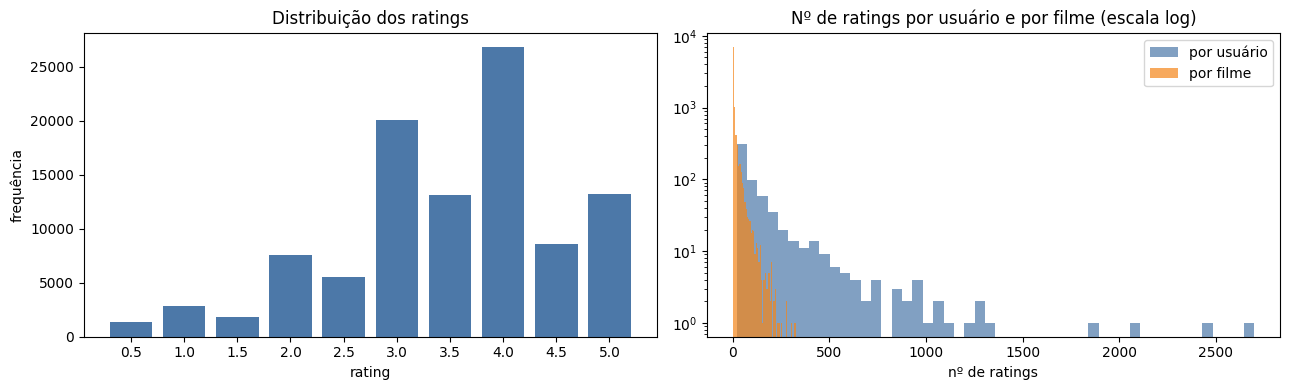

Rating médio: 3.502 | mediana: 3.5
Ratings/usuário  → min 20, mediana 70, max 2698
Ratings/filme    → min 1, mediana 3, max 329


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color="#4C78A8")
axes[0].set_title("Distribuição dos ratings")
axes[0].set_xlabel("rating")
axes[0].set_ylabel("frequência")

per_user = ratings.groupby("userId").size()
per_item = ratings.groupby("movieId").size()
axes[1].hist(per_user, bins=50, alpha=0.7, label="por usuário", color="#4C78A8")
axes[1].hist(per_item, bins=50, alpha=0.7, label="por filme", color="#F58518")
axes[1].set_yscale("log")
axes[1].set_title("Nº de ratings por usuário e por filme (escala log)")
axes[1].set_xlabel("nº de ratings")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Rating médio: {ratings['rating'].mean():.3f} | "
      f"mediana: {ratings['rating'].median()}")
print(f"Ratings/usuário  → min {per_user.min()}, "
      f"mediana {int(per_user.median())}, max {per_user.max()}")
print(f"Ratings/filme    → min {per_item.min()}, "
      f"mediana {int(per_item.median())}, max {per_item.max()}")

**Long-tail (curva de popularidade).** Poucos filmes concentram a maioria das
interações — padrão universal em recomendação e a principal razão de baselines de
popularidade serem competitivos.

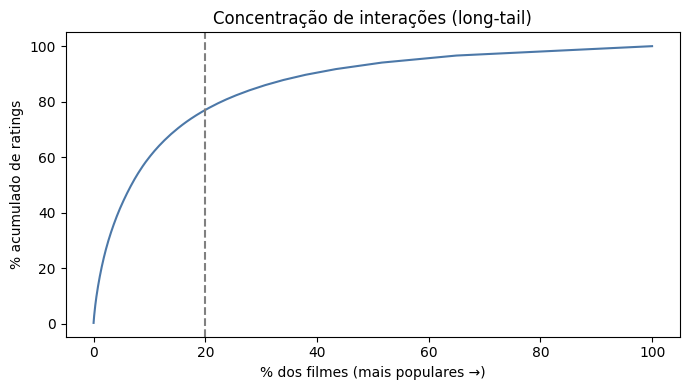

Os 20% de filmes mais populares concentram 77.0% de todas as interações.


In [6]:
sorted_pop = per_item.sort_values(ascending=False).values
cum = np.cumsum(sorted_pop) / sorted_pop.sum()
share_20 = cum[int(0.2 * len(cum))]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(len(cum)) / len(cum) * 100, cum * 100, color="#4C78A8")
ax.axvline(20, ls="--", color="grey")
ax.set_xlabel("% dos filmes (mais populares →)")
ax.set_ylabel("% acumulado de ratings")
ax.set_title("Concentração de interações (long-tail)")
plt.tight_layout()
plt.show()
print(f"Os 20% de filmes mais populares concentram "
      f"{share_20 * 100:.1f}% de todas as interações.")

**Deriva temporal** — volume de avaliações por ano. Se o comportamento muda ao
longo do tempo, avaliar com um *holdout* temporal é mais honesto do que split aleatório.

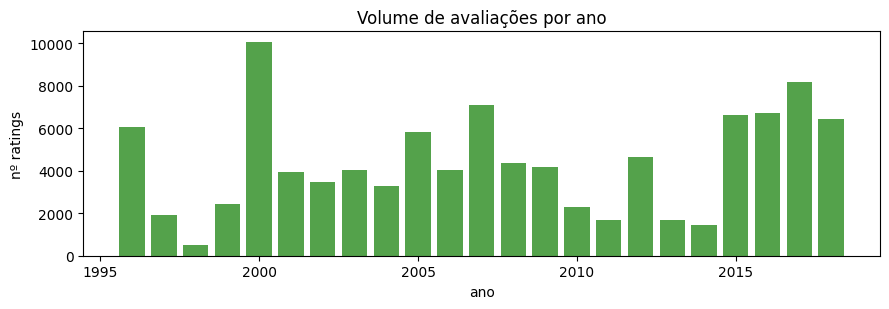

In [7]:
by_year = ratings.set_index("datetime").resample("YE").size()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar([d.year for d in by_year.index], by_year.values, color="#54A24B")
ax.set_title("Volume de avaliações por ano")
ax.set_xlabel("ano")
ax.set_ylabel("nº ratings")
plt.tight_layout()
plt.show()

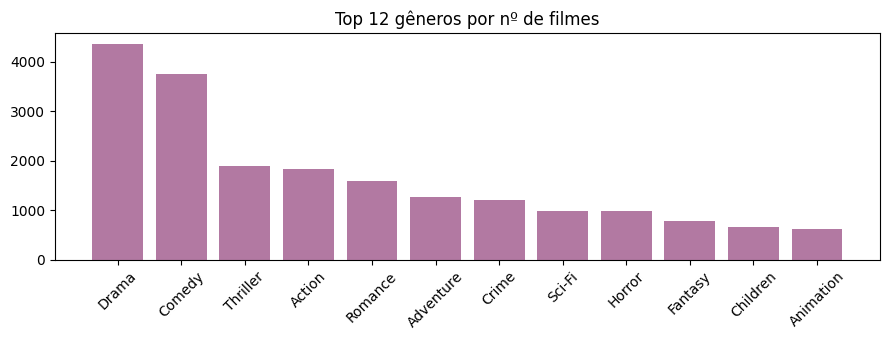

Gêneros distintos: 20


In [8]:
# Gêneros mais frequentes (metadados para interpretação posterior)
genres = movies["genres"].str.get_dummies(sep="|")
top_genres = genres.sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(top_genres.index[:12], top_genres.values[:12], color="#B279A2")
ax.set_title("Top 12 gêneros por nº de filmes")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print("Gêneros distintos:", genres.shape[1])

## 4. Pré-processamento e split temporal por usuário

Decisões-chave:

- **Encoding contíguo**: `userId`/`movieId` originais são esparsos; mapeamos para
  índices `0..N-1` para alimentar as `nn.Embedding`.
- **Split temporal *por usuário***: para cada usuário, ordenamos por tempo e reservamos
  os **15% finais** para teste e os **15% anteriores** para validação. Isso simula prever
  o *futuro* de cada usuário (mais realista que split aleatório) e **garante que todo
  usuário aparece no treino** (evita cold-start artificial).
- **Filtragem de vazamento**: itens que aparecem só em val/test (nunca no treino) são
  removidos — o modelo não pode ter embedding para um item que nunca viu.

In [9]:
def encode_ids(df: pd.DataFrame) -> tuple[pd.DataFrame, dict, dict]:
    """Mapeia userId/movieId para índices contíguos 0..N-1."""
    user_map = {u: i for i, u in enumerate(df["userId"].unique())}
    item_map = {m: i for i, m in enumerate(df["movieId"].unique())}
    out = df.copy()
    out["u"] = out["userId"].map(user_map)
    out["i"] = out["movieId"].map(item_map)
    return out, user_map, item_map


def split_per_user(df: pd.DataFrame, val_frac: float, test_frac: float) -> tuple:
    """Split temporal por usuário: cauda recente vira val e test."""
    df = df.sort_values(["u", "timestamp"])
    tr, va, te = [], [], []
    for _, g in df.groupby("u", sort=False):
        n = len(g)
        n_te = max(1, int(round(n * test_frac)))
        n_va = max(1, int(round(n * val_frac)))
        te.append(g.iloc[n - n_te:])
        va.append(g.iloc[n - n_te - n_va: n - n_te])
        tr.append(g.iloc[: n - n_te - n_va])
    return pd.concat(tr), pd.concat(va), pd.concat(te)

In [10]:
data, user_map, item_map = encode_ids(ratings)
train_df, val_df, test_df = split_per_user(data, CFG.val_frac, CFG.test_frac)

# Remove itens de val/test não vistos no treino (evita vazamento de embedding)
seen_items = set(train_df["i"].unique())
val_df = val_df[val_df["i"].isin(seen_items)].copy()
test_df = test_df[test_df["i"].isin(seen_items)].copy()

N_USERS, N_ITEMS = len(user_map), len(item_map)
GLOBAL_MEAN = float(train_df["rating"].mean())
print(f"Treino: {len(train_df):,} | Val: {len(val_df):,} | Teste: {len(test_df):,}")
print(f"Usuários: {N_USERS} | Itens: {N_ITEMS} | "
      f"média global (treino): {GLOBAL_MEAN:.3f}")

Treino: 70,614 | Val: 13,925 | Teste: 13,603
Usuários: 610 | Itens: 9724 | média global (treino): 3.522


## 5. Baselines e funções de métrica

Antes da rede neural, estabelecemos referências fortes. Os requisitos pedem comparação com
**baselines Scikit-Learn** e **≥ 4 métricas** — aqui vamos ao **máximo tecnicamente
coerente** para recomendação, cobrindo as três grandes famílias de RecSys clássico:

| Baseline | Família | Biblioteca |
|---|---|---|
| `GlobalMean` | referência trivial (piso) | numpy |
| `UserItemBias` | modelo de viés (mu + b_u + b_i) | pandas/numpy |
| `SVD` | **fatoração de matriz** latente | **`sklearn.decomposition.TruncatedSVD`** |
| `NMF` | fatoração **não-negativa** | **`sklearn.decomposition.NMF`** |
| `ItemKNN` | **CF memória** (vizinhança item-item) | **`sklearn.neighbors.NearestNeighbors`** |
| `GBRT` | **ML supervisionado** sobre features | **`sklearn.ensemble.HistGradientBoostingRegressor`** |

São **4 modelos Scikit-Learn** de paradigmas distintos + 2 referências estatísticas.

**Padrões de projeto (requisitos).** Uma base `MatrixRecommender` implementa `predict`/`score`
uma única vez (**Template Method**); cada baseline só preenche a matriz `recon`. Um
**Factory** (`build_baselines`) instancia e treina todos. E o avaliador de ranking recebe
a *função de score* (**Strategy**) — o mesmo avaliador serve a baselines e à rede neural.

**Métricas**
- *Predição*: **RMSE**, **MAE** (via `sklearn.metrics`).
- *Ranking Top-K*: **Precision@K**, **Recall@K**, **NDCG@K** e **cobertura de catálogo**.

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.sparse import csr_matrix

RATING_RANGE = (0.5, 5.0)


def train_matrix(df: pd.DataFrame, values: np.ndarray) -> csr_matrix:
    """Monta a matriz esparsa usuários×itens a partir de (u, i, values)."""
    rows, cols = df["u"].to_numpy(), df["i"].to_numpy()
    return csr_matrix((values, (rows, cols)), shape=(N_USERS, N_ITEMS))


class MatrixRecommender:
    """Base (Template Method): subclasses só preenchem `recon` (score usuário×item)."""

    recon: np.ndarray

    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return np.clip(self.recon[users, items], *RATING_RANGE).astype(np.float32)

    def score(self, user: int) -> np.ndarray:
        return self.recon[user]


class GlobalMeanModel:
    """Baseline trivial (piso): prevê sempre a média global de ratings."""

    def __init__(self, global_mean: float) -> None:
        self.global_mean = global_mean

    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return np.full(len(users), self.global_mean, dtype=np.float32)


class UserItemBiasModel(MatrixRecommender):
    """Viés clássico de RecSys: mu + b_user + b_item (regularizado por contagem)."""

    def __init__(self, global_mean: float, reg: float = 10.0) -> None:
        self.mu, self.reg = global_mean, reg

    def fit(self, df: pd.DataFrame) -> "UserItemBiasModel":
        dev = df["rating"] - self.mu
        gi = dev.groupby(df["i"])
        b_item = gi.sum() / (gi.count() + self.reg)
        resid = dev - df["i"].map(b_item)
        gu = resid.groupby(df["u"])
        b_user = gu.sum() / (gu.count() + self.reg)
        bu = b_user.reindex(range(N_USERS)).fillna(0.0).to_numpy()
        bi = b_item.reindex(range(N_ITEMS)).fillna(0.0).to_numpy()
        self.recon = self.mu + bu[:, None] + bi[None, :]
        return self

In [12]:
class SVDRecommender(MatrixRecommender):
    """Fatoração de matriz com TruncatedSVD (Scikit-Learn) sobre resíduos."""

    def __init__(self, global_mean: float, n_components: int = 32,
                 seed: int = SEED) -> None:
        self.mu = global_mean
        self.svd = TruncatedSVD(n_components=n_components, random_state=seed)

    def fit(self, df: pd.DataFrame) -> "SVDRecommender":
        residual = train_matrix(df, (df["rating"] - self.mu).to_numpy(np.float32))
        embedded = self.svd.fit_transform(residual)          # U · S
        self.recon = self.mu + embedded @ self.svd.components_
        return self


class NMFRecommender(MatrixRecommender):
    """Fatoração não-negativa (NMF, Scikit-Learn) sobre a matriz de ratings."""

    def __init__(self, n_components: int = 32, seed: int = SEED) -> None:
        self.nmf = NMF(n_components=n_components, init="nndsvda",
                       max_iter=600, random_state=seed)

    def fit(self, df: pd.DataFrame) -> "NMFRecommender":
        matrix = train_matrix(df, df["rating"].to_numpy(np.float32))
        w = self.nmf.fit_transform(matrix)
        self.recon = w @ self.nmf.components_
        return self

In [13]:
def item_similarity(item_user: csr_matrix, k: int) -> csr_matrix:
    """Similaridade cosseno esparsa item-item, mantendo os k vizinhos por item."""
    knn = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(item_user)
    dist, idx = knn.kneighbors(item_user)
    n = item_user.shape[0]
    rows = np.repeat(np.arange(n), k + 1)
    sim = csr_matrix((1.0 - dist.ravel(), (rows, idx.ravel())), shape=(n, n))
    sim.setdiag(0.0)
    sim.eliminate_zeros()
    norm = np.abs(sim).sum(axis=1).A.ravel()
    norm[norm == 0] = 1.0
    return sim.multiply(1.0 / norm[:, None]).tocsr()


class ItemKNNRecommender(MatrixRecommender):
    """CF item-item baseada em memória: kNN com cosseno (Scikit-Learn)."""

    def __init__(self, k: int = 40) -> None:
        self.k = k

    def fit(self, df: pd.DataFrame) -> "ItemKNNRecommender":
        item_mean = (df.groupby("i")["rating"].mean()
                     .reindex(range(N_ITEMS)).fillna(GLOBAL_MEAN).to_numpy())
        dev = df["rating"].to_numpy(np.float32) - item_mean[df["i"].to_numpy()]
        centered = train_matrix(df, dev.astype(np.float32))
        sim = item_similarity(centered.T.tocsr(), self.k)
        self.recon = item_mean[None, :] + (centered @ sim.T).toarray()
        return self

In [14]:
def agg_feature(df: pd.DataFrame, col: str, how: str, size: int,
                fill: float) -> np.ndarray:
    """Agregado (mean/size) por coluna, reindexado ao catálogo com preenchimento."""
    grp = df.groupby(col)["rating"]
    series = grp.size() if how == "size" else grp.agg(how)
    return series.reindex(range(size)).fillna(fill).to_numpy(dtype=np.float32)


class GBRTRecommender(MatrixRecommender):
    """Gradient Boosting (HistGradientBoostingRegressor) sobre features tabulares."""

    def __init__(self, seed: int = SEED) -> None:
        self.model = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, early_stopping=True,
            random_state=seed)

    def fit(self, df: pd.DataFrame) -> "GBRTRecommender":
        self._build_lookups(df)
        features = self._features(df["u"].to_numpy(), df["i"].to_numpy())
        self.model.fit(features, df["rating"].to_numpy())
        self.recon = self._full_recon()
        return self

    def _build_lookups(self, df: pd.DataFrame) -> None:
        self.user_mean = agg_feature(df, "u", "mean", N_USERS, GLOBAL_MEAN)
        self.user_count = agg_feature(df, "u", "size", N_USERS, 0.0)
        self.item_mean = agg_feature(df, "i", "mean", N_ITEMS, GLOBAL_MEAN)
        self.item_count = agg_feature(df, "i", "size", N_ITEMS, 0.0)

    def _features(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return np.column_stack([self.user_mean[users], self.user_count[users],
                                self.item_mean[items], self.item_count[items]])

    def _full_recon(self) -> np.ndarray:
        items = np.arange(N_ITEMS)
        recon = np.empty((N_USERS, N_ITEMS), dtype=np.float32)
        for u in range(N_USERS):
            recon[u] = self.model.predict(self._features(np.full(N_ITEMS, u), items))
        return recon

In [15]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(math.sqrt(mean_squared_error(y_true, y_pred)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(mean_absolute_error(y_true, y_pred))


def dcg_at_k(relevances: list[int], k: int) -> float:
    """Discounted Cumulative Gain nas primeiras k posições."""
    return sum(rel / math.log2(idx + 2) for idx, rel in enumerate(relevances[:k]))


def ranking_metrics(recommended: list[int], relevant: set[int],
                    k: int) -> tuple[float, float, float]:
    """Retorna (precision@k, recall@k, ndcg@k) para um usuário."""
    top = recommended[:k]
    hits = [1 if item in relevant else 0 for item in top]
    precision = sum(hits) / k
    recall = sum(hits) / len(relevant) if relevant else 0.0
    ideal = dcg_at_k(sorted(hits, reverse=True), k)
    ndcg = dcg_at_k(hits, k) / ideal if ideal > 0 else 0.0
    return precision, recall, ndcg

### Avaliador de ranking reutilizável

Para métricas Top-K precisamos, para cada usuário, **pontuar todos os itens do catálogo**,
remover os já vistos no treino e comparar o Top-K com os itens **relevantes** do teste
(rating ≥ 4). Encapsulamos isso numa função que recebe uma *função de score* — assim o
**mesmo avaliador** serve para baselines e para a rede neural (padrão *Strategy*).

In [16]:
def build_user_histories() -> tuple[dict, dict]:
    """Itens vistos no treino e itens relevantes no teste, por usuário."""
    train_seen = train_df.groupby("u")["i"].apply(set).to_dict()
    rel = test_df[test_df["rating"] >= CFG.relevance_threshold]
    test_relevant = rel.groupby("u")["i"].apply(set).to_dict()
    return train_seen, test_relevant


def evaluate_ranking(score_fn, k: int = CFG.top_k) -> dict[str, float]:
    """Precision/Recall/NDCG@k médios + cobertura, dado score_fn(u)->vetor de scores."""
    train_seen, test_relevant = build_user_histories()
    all_items = np.arange(N_ITEMS)
    precs, recs, ndcgs, recommended_pool = [], [], [], set()
    for u, relevant in test_relevant.items():
        if not relevant:
            continue
        scores = score_fn(u).copy()
        scores[list(train_seen.get(u, set()))] = -np.inf   # não recomenda o já visto
        top = all_items[np.argpartition(-scores, k)[:k]]
        top = top[np.argsort(-scores[top])].tolist()
        p, r, nd = ranking_metrics(top, relevant, k)
        precs.append(p)
        recs.append(r)
        ndcgs.append(nd)
        recommended_pool.update(top)
    return {"Precision@10": np.mean(precs), "Recall@10": np.mean(recs),
            "NDCG@10": np.mean(ndcgs), "Coverage": len(recommended_pool) / N_ITEMS}

In [17]:
def build_baselines() -> dict[str, object]:
    """Factory: instancia e treina todos os baselines de referência."""
    return {
        "GlobalMean": GlobalMeanModel(GLOBAL_MEAN),
        "UserItemBias": UserItemBiasModel(GLOBAL_MEAN).fit(train_df),
        "SVD (sklearn)": SVDRecommender(GLOBAL_MEAN).fit(train_df),
        "NMF (sklearn)": NMFRecommender().fit(train_df),
        "ItemKNN (sklearn)": ItemKNNRecommender().fit(train_df),
        "GBRT (sklearn)": GBRTRecommender().fit(train_df),
    }


baselines = build_baselines()
print("Baselines treinados:", ", ".join(baselines))

Baselines treinados: GlobalMean, UserItemBias, SVD (sklearn), NMF (sklearn), ItemKNN (sklearn), GBRT (sklearn)


In [18]:
# Avalia todos os baselines: RMSE/MAE (predição) + ranking Top-K quando aplicável
y_test = test_df["rating"].to_numpy(dtype=np.float32)
u_test, i_test = test_df["u"].to_numpy(), test_df["i"].to_numpy()

baseline_results: dict[str, dict[str, float]] = {}
for name, model in baselines.items():
    pred = model.predict(u_test, i_test)
    row = {"RMSE": rmse(y_test, pred), "MAE": mae(y_test, pred)}
    if isinstance(model, MatrixRecommender):
        row.update(evaluate_ranking(model.score))
    baseline_results[name] = row

pd.DataFrame(baseline_results).T.round(4)

,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
GlobalMean,1.0546,0.8275,NaN,NaN,NaN,NaN
UserItemBias,0.8996,0.6957,0.0303,0.0356,0.1196,0.0051
SVD (sklearn),1.0282,0.8040,0.0487,0.0565,0.1700,0.0528
NMF (sklearn),3.0310,2.8371,0.0491,0.0691,0.1616,0.0535
ItemKNN (sklearn),1.0032,0.7713,0.0003,0.0001,0.0016,0.0187
GBRT (sklearn),0.9377,0.7132,0.0007,0.0001,0.0036,0.0198


## 6. Rede neural (PyTorch) — embeddings + MLP + bias

Arquitetura **embedding-based** (a família pedida no enunciado). Para cada par
(usuário, item):

1. `nn.Embedding` gera vetores latentes de usuário e de item.
2. Os vetores são **concatenados** e passam por um **MLP** (camadas ocultas + ReLU + dropout).
3. Somamos **viés de usuário**, **viés de item** e **viés global**.
4. Uma sigmoide reescala a saída para o intervalo `[0.5, 5.0]` — o modelo só prevê ratings válidos.

É o esqueleto do *Neural Collaborative Filtering*: combina fatoração (embeddings) com a
não-linearidade de um MLP. Código com type hints e blocos curtos, pronto para migrar a
`src/models/`.

In [19]:
class NeuralRecommender(nn.Module):
    """Recomendador neural: embeddings de usuário/item + MLP + termos de viés."""

    def __init__(self, n_users: int, n_items: int, cfg: Config,
                 rating_range: tuple[float, float] = (0.5, 5.0)) -> None:
        super().__init__()
        self.user_emb = nn.Embedding(n_users, cfg.embedding_dim)
        self.item_emb = nn.Embedding(n_items, cfg.embedding_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.mlp = self._build_mlp(cfg)
        self.low, self.high = rating_range
        self._init_weights()

    def _build_mlp(self, cfg: Config) -> nn.Sequential:
        layers: list[nn.Module] = []
        in_dim = cfg.embedding_dim * 2
        for out_dim in cfg.mlp_layers:
            layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(cfg.dropout)]
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        return nn.Sequential(*layers)

    def _init_weights(self) -> None:
        for emb in (self.user_emb, self.item_emb):
            nn.init.normal_(emb.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users: torch.Tensor, items: torch.Tensor) -> torch.Tensor:
        u, v = self.user_emb(users), self.item_emb(items)
        x = torch.cat([u, v], dim=1)
        out = self.mlp(x).squeeze(1)
        out = out + self.user_bias(users).squeeze(1) + self.item_bias(items).squeeze(1)
        return self.low + (self.high - self.low) * torch.sigmoid(out)

In [20]:
def make_loader(df: pd.DataFrame, batch_size: int, shuffle: bool) -> DataLoader:
    """Cria um DataLoader de tensores (u, i, rating) a partir do DataFrame."""
    ds = TensorDataset(
        torch.tensor(df["u"].to_numpy(), dtype=torch.long),
        torch.tensor(df["i"].to_numpy(), dtype=torch.long),
        torch.tensor(df["rating"].to_numpy(), dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


train_loader = make_loader(train_df, CFG.batch_size, shuffle=True)
val_loader = make_loader(val_df, CFG.batch_size, shuffle=False)
print(f"Batches — treino: {len(train_loader)} | val: {len(val_loader)}")

Batches — treino: 69 | val: 14


## 7. Treino com early stopping

Loop de treino padrão PyTorch: `MSELoss`, otimizador Adam com `weight_decay`
(regularização L2) e **early stopping** monitorando o RMSE de validação — os requisitos exigem
early stopping explicitamente. Guardamos o melhor estado do modelo (`best_state`).

In [21]:
def run_epoch(model: nn.Module, loader: DataLoader, loss_fn: nn.Module,
              optimizer: torch.optim.Optimizer | None = None) -> float:
    """Executa uma época (treino se optimizer != None) e devolve o RMSE."""
    training = optimizer is not None
    model.train(training)
    total_se, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for users, items, y in loader:
            users, items, y = users.to(DEVICE), items.to(DEVICE), y.to(DEVICE)
            pred = model(users, items)
            loss = loss_fn(pred, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_se += loss.item() * len(y)
            n += len(y)
    return math.sqrt(total_se / n)

In [22]:
def train_model(model: nn.Module, cfg: Config) -> dict:
    """Treina com early stopping; retorna histórico e melhor RMSE de validação."""
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    history = {"train_rmse": [], "val_rmse": []}
    best_val, best_state, wait = float("inf"), None, 0
    for epoch in range(1, cfg.max_epochs + 1):
        tr = run_epoch(model, train_loader, loss_fn, optimizer)
        va = run_epoch(model, val_loader, loss_fn)
        history["train_rmse"].append(tr)
        history["val_rmse"].append(va)
        if va < best_val - 1e-4:
            best_val = va
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        print(f"época {epoch:02d} | treino RMSE {tr:.4f} | val RMSE {va:.4f}"
              f"{'  <- melhor' if wait == 0 else ''}")
        if wait >= cfg.patience:
            print(f"Early stopping na época {epoch} (melhor val RMSE {best_val:.4f}).")
            break
    model.load_state_dict(best_state)
    return {"history": history, "best_val_rmse": best_val, "epochs": epoch}

In [23]:
set_seed(CFG.seed)
model = NeuralRecommender(N_USERS, N_ITEMS, CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis: {n_params:,}\n")
train_info = train_model(model, CFG)

Parâmetros treináveis: 347,807



época 01 | treino RMSE 1.3604 | val RMSE 1.0475  <- melhor


época 02 | treino RMSE 0.9531 | val RMSE 0.8938  <- melhor


época 03 | treino RMSE 0.8750 | val RMSE 0.8831  <- melhor


época 04 | treino RMSE 0.8522 | val RMSE 0.8813  <- melhor


época 05 | treino RMSE 0.8390 | val RMSE 0.8782  <- melhor


época 06 | treino RMSE 0.8309 | val RMSE 0.8788


época 07 | treino RMSE 0.8235 | val RMSE 0.8783


época 08 | treino RMSE 0.8175 | val RMSE 0.8807


época 09 | treino RMSE 0.8133 | val RMSE 0.8787
Early stopping na época 9 (melhor val RMSE 0.8782).


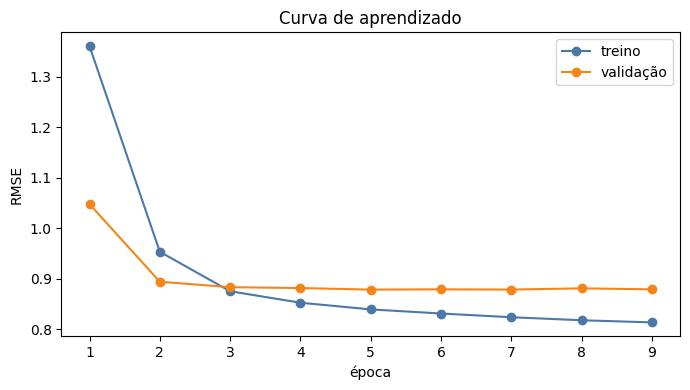

In [24]:
h = train_info["history"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(h["train_rmse"]) + 1), h["train_rmse"], "-o",
        label="treino", color="#4C78A8")
ax.plot(range(1, len(h["val_rmse"]) + 1), h["val_rmse"], "-o",
        label="validação", color="#F58518")
ax.set_xlabel("época")
ax.set_ylabel("RMSE")
ax.set_title("Curva de aprendizado")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Avaliação profunda — modelo neural vs. baselines

Aplicamos ao modelo treinado exatamente as mesmas métricas dos baselines: **RMSE** e
**MAE** (predição) e **Precision@10 / Recall@10 / NDCG@10 / Cobertura** (ranking).
A comparação lado a lado é o coração da avaliação exigida (≥ 4 métricas).

In [25]:
@torch.no_grad()
def predict_pairs(model: nn.Module, users: np.ndarray, items: np.ndarray,
                  batch: int = 8192) -> np.ndarray:
    """Prediz ratings para pares (u, i) em lotes."""
    model.eval()
    out = []
    for s in range(0, len(users), batch):
        u = torch.tensor(users[s:s + batch], dtype=torch.long, device=DEVICE)
        i = torch.tensor(items[s:s + batch], dtype=torch.long, device=DEVICE)
        out.append(model(u, i).cpu().numpy())
    return np.concatenate(out)


@torch.no_grad()
def neural_score(u: int) -> np.ndarray:
    """Score do modelo para o usuário u contra todo o catálogo."""
    model.eval()
    users = torch.full((N_ITEMS,), u, dtype=torch.long, device=DEVICE)
    items = torch.arange(N_ITEMS, dtype=torch.long, device=DEVICE)
    return model(users, items).cpu().numpy()

In [26]:
nn_pred = predict_pairs(model, u_test, i_test)
neural_results = {"RMSE": rmse(y_test, nn_pred), "MAE": mae(y_test, nn_pred)}
neural_results.update(evaluate_ranking(neural_score))

all_results = {**baseline_results, "NeuralRecommender": neural_results}
comparison = pd.DataFrame(all_results).T[
    ["RMSE", "MAE", "Precision@10", "Recall@10", "NDCG@10", "Coverage"]
]
comparison.round(4)

,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
GlobalMean,1.0546,0.8275,NaN,NaN,NaN,NaN
UserItemBias,0.8996,0.6957,0.0303,0.0356,0.1196,0.0051
SVD (sklearn),1.0282,0.8040,0.0487,0.0565,0.1700,0.0528
NMF (sklearn),3.0310,2.8371,0.0491,0.0691,0.1616,0.0535
ItemKNN (sklearn),1.0032,0.7713,0.0003,0.0001,0.0016,0.0187
GBRT (sklearn),0.9377,0.7132,0.0007,0.0001,0.0036,0.0198
NeuralRecommender,0.8984,0.6911,0.0079,0.0087,0.0553,0.0031


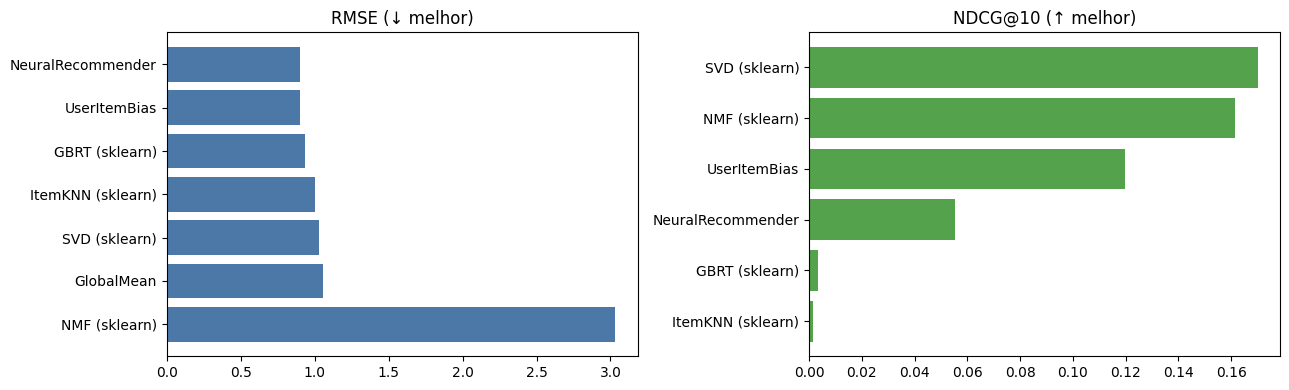

In [27]:
# Visual: RMSE (menor = melhor) e NDCG@10 (maior = melhor) lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comp = comparison.dropna(subset=["RMSE"]).sort_values("RMSE")
axes[0].barh(comp.index, comp["RMSE"], color="#4C78A8")
axes[0].set_title("RMSE (↓ melhor)")
axes[0].invert_yaxis()
rank = comparison.dropna(subset=["NDCG@10"]).sort_values("NDCG@10")
axes[1].barh(rank.index, rank["NDCG@10"], color="#54A24B")
axes[1].set_title("NDCG@10 (↑ melhor)")
plt.tight_layout()
plt.show()

**Como ler os resultados — leitura crítica.** O achado central é que **nenhum modelo
vence em tudo** — e é exatamente isso que uma avaliação profunda deve expor:

- **Melhor predição de rating (RMSE/MAE):** `NeuralRecommender` (≈ 0.898 / 0.691),
  empatado com `UserItemBias` e seguido de perto pelo `GBRT`. Modelos otimizados para
  *erro de nota* dominam aqui.
- **Melhor ranking Top-10 (Precision/Recall/NDCG):** as **fatorações latentes**
  (`SVD` e `NMF`) vencem (NDCG ≈ 0.16–0.17), bem à frente da rede neural (≈ 0.055).
- **`ItemKNN` e `GBRT`:** boa nota pontual, mas ranking fraco — ranqueiam por sinais de
  popularidade/desvio que discriminam mal os itens *não vistos* de cada usuário.
- **`NMF` tem RMSE alto (≈ 3.0) de valor didático:** aplicada à matriz esparsa com as
  ausências tratadas como zero, ela subestima a *escala absoluta* (péssimo RMSE) mas
  preserva muito bem a *ordem* (ótimo ranking). É o caso clássico de por que
  **avaliar numa métrica só engana**.

**Conclusão da avaliação:** o *"melhor modelo" depende do objetivo de negócio* — estimar
a nota (regressão) ≠ montar uma lista ranqueada (recomendação). A rede, dominada pelos
termos de bias, recomenda clássicos de alto viés para todo mundo (§10) e por isso perde
no Top-K. O próximo passo para produção é treiná-la com *feedback implícito* e perda de
ranking (BPR / sampled-softmax) — experimentos que o **MLflow** deve rastrear (≥ 3 runs),
comparando exatamente esta tabela entre versões. **Reportar as duas famílias de métrica
é o que torna a avaliação honesta.**

## 9. Interpretação dos embeddings

Um modelo de recomendação não precisa ser uma caixa-preta. Aplicamos duas leituras
padrão de interpretabilidade em RecSys: o **viés de item** aprendido aproxima a
"qualidade geral" do filme (corrigida por popularidade e pela severidade de quem avalia),
e o **PCA dos embeddings** revela eixos latentes de gosto. Ambas viram insumo direto para
o *Model Card* (Etapa 4).

In [28]:
idx_to_movieid = {v: k for k, v in item_map.items()}
title_by_movieid = movies.set_index("movieId")["title"].to_dict()
pop = train_df.groupby("i").size()
frequent = pop[pop >= 30].index.to_numpy()   # só filmes com sinal suficiente

item_bias = model.item_bias.weight.detach().cpu().numpy().ravel()
ranked = sorted(frequent, key=lambda i: item_bias[i], reverse=True)


def titles(indices: list[int]) -> list[str]:
    return [title_by_movieid.get(idx_to_movieid[i], "?") for i in indices]


print("🏆 Maior viés aprendido (melhores):")
for t in titles(ranked[:10]):
    print("   ", t)
print("\n👎 Menor viés aprendido (piores):")
for t in titles(ranked[-10:]):
    print("   ", t)

🏆 Maior viés aprendido (melhores):
    Goodfellas (1990)
    Star Wars: Episode V - The Empire Strikes Back (1980)
    Lord of the Rings: The Two Towers, The (2002)
    Shawshank Redemption, The (1994)
    Monty Python and the Holy Grail (1975)
    Forrest Gump (1994)
    Pulp Fiction (1994)
    Schindler's List (1993)
    Braveheart (1995)
    Star Wars: Episode IV - A New Hope (1977)

👎 Menor viés aprendido (piores):
    Johnny Mnemonic (1995)
    Planet of the Apes (2001)
    Nine Months (1995)
    Charlie's Angels (2000)
    Mortal Kombat (1995)
    City Slickers II: The Legend of Curly's Gold (1994)
    Flintstones, The (1994)
    Coneheads (1993)
    Wild Wild West (1999)
    Batman & Robin (1997)


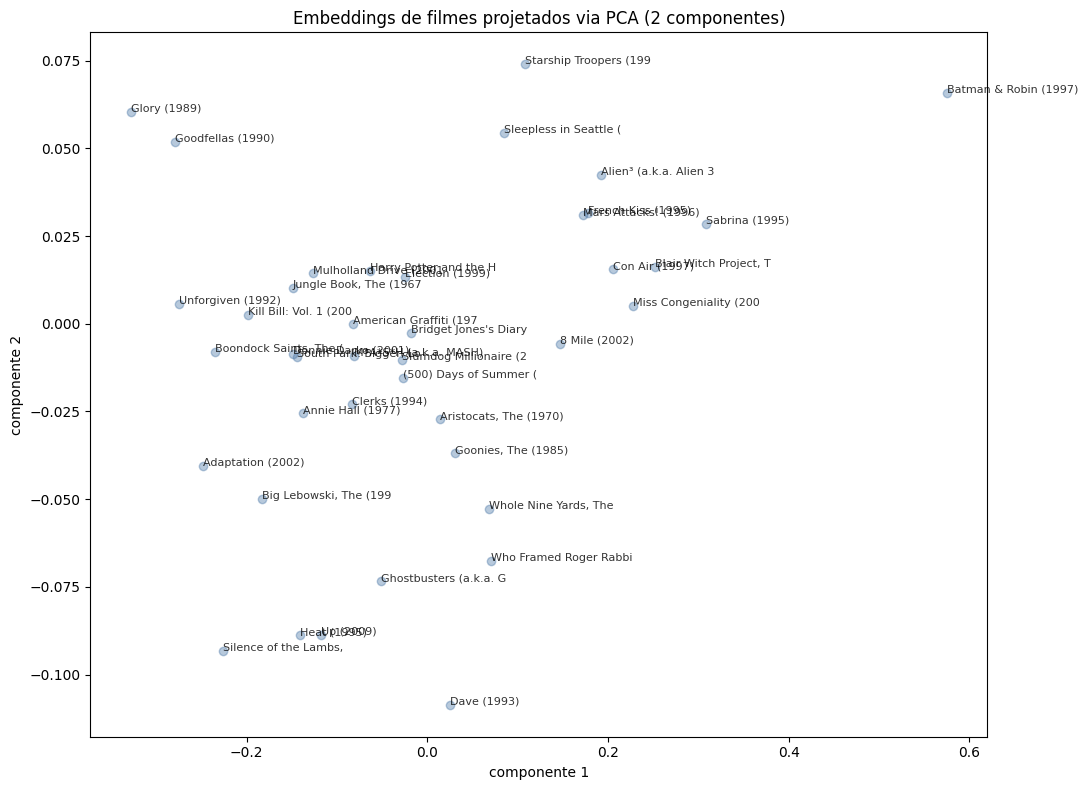

Variância explicada pelos 2 componentes: 31.2%


In [29]:
from sklearn.decomposition import PCA

emb = model.item_emb.weight.detach().cpu().numpy()[frequent]
pca = PCA(n_components=2, random_state=SEED).fit(emb)
coords = pca.transform(emb)

sample = np.random.choice(len(frequent), size=min(40, len(frequent)), replace=False)
fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(coords[sample, 0], coords[sample, 1], alpha=0.4, color="#4C78A8")
for s in sample:
    name = title_by_movieid.get(idx_to_movieid[frequent[s]], "?")[:22]
    ax.annotate(name, (coords[s, 0], coords[s, 1]), fontsize=8, alpha=0.8)
ax.set_title("Embeddings de filmes projetados via PCA (2 componentes)")
ax.set_xlabel("componente 1")
ax.set_ylabel("componente 2")
plt.tight_layout()
plt.show()
explicada = pca.explained_variance_ratio_.sum()
print(f"Variância explicada pelos 2 componentes: {explicada:.1%}")

## 10. Exemplo de recomendação Top-N

Fechando o ciclo: para um usuário real, mostramos o que ele **mais gostou** (histórico de
treino) e as **10 recomendações** do modelo entre filmes que ele ainda não viu — o
produto final do sistema.

In [30]:
def recommend(user_idx: int, k: int = 10) -> pd.DataFrame:
    """Top-k recomendações para um usuário, excluindo itens já vistos no treino."""
    scores = neural_score(user_idx)
    seen = set(train_df.loc[train_df["u"] == user_idx, "i"])
    scores[list(seen)] = -np.inf
    top = np.argsort(-scores)[:k]
    return pd.DataFrame({
        "filme": [title_by_movieid.get(idx_to_movieid[i], "?") for i in top],
        "score_previsto": np.round(scores[top], 3),
    })


demo_user = int(train_df["u"].value_counts().index[5])
liked = (train_df[train_df["u"] == demo_user]
         .sort_values("rating", ascending=False).head(5))
print(f"Usuário {demo_user} — favoritos no histórico:")
for _, row in liked.iterrows():
    titulo = title_by_movieid.get(idx_to_movieid[row["i"]], "?")
    print(f"   {row['rating']:.1f}  {titulo}")
print("\n🎯 Recomendações do modelo:")
recommend(demo_user, CFG.top_k)

Usuário 609 — favoritos no histórico:
   5.0  Fight Club (1999)
   5.0  Inglourious Basterds (2009)
   5.0  Bourne Ultimatum, The (2007)
   5.0  Mulholland Drive (2001)
   5.0  Drive (2011)

🎯 Recomendações do modelo:


,filme,score_previsto
0,Double Indemnity (1944),4.546
1,"Streetcar Named Desire, A (1951)",4.535
2,Ran (1985),4.534
3,Harold and Maude (1971),4.526
4,High Noon (1952),4.523
5,"Philadelphia Story, The (1940)",4.521
6,His Girl Friday (1940),4.515
7,Touch of Evil (1958),4.512
8,On the Waterfront (1954),4.508
9,Seven Samurai (Shichinin no samurai) (1954),4.505


## 11. Conclusão — adequação ao Tech Challenge e roadmap

### Veredito: este notebook **serve como núcleo de modelagem** do trabalho ✅
Ele já entrega, de forma reprodutível, os itens **de dados e modelo** dos requisitos:

| Requisito | Status neste notebook |
|---|---|
| Rede neural PyTorch (MLP/embedding-based) | ✅ `NeuralRecommender` (embeddings + MLP + bias) |
| Early stopping | ✅ na rede (val RMSE) e no `GBRT` (sklearn) |
| Comparação com baselines Scikit-Learn | ✅ **4 modelos sklearn** — `TruncatedSVD`, `NMF`, `ItemKNN`, `HistGradientBoostingRegressor` — + 2 referências estatísticas |
| ≥ 4 métricas | ✅ **6**: RMSE, MAE, Precision@10, Recall@10, NDCG@10, Coverage |
| Dataset ≥ 10.000 interações user-item | ✅ 100.836 ratings (validado por `assert`) |
| Seeds fixados / device-agnostic | ✅ `set_seed` + `DEVICE` |
| Clean code (funções curtas, type hints, docstrings) | ✅ ao longo do notebook, `ruff` limpo |
| Design patterns | ✅ **Template Method** (`MatrixRecommender`), **Factory** (`build_baselines`), **Strategy** (avaliador recebe `score_fn`) |
